# Analysis and creating figures
This notebook contains the code for visualising findings.


In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import calendar
import plotly.express as px
import numpy as np
from math import ceil
import numpy as np
from scipy.stats import chi2_contingency


## Data Loading

Load the cleaned dataset (`cleaned_final_df.csv`) and ensure the date column is parsed correctly.

In [2]:
# import df
df = pd.read_csv('../tweede_kamer_with_topics.csv', index_col=0)
df.head()

,title,year,ai_related,company_hits,body,matched_keywords_all,type,persons,orgs,countries,...,nouns,adjectives,verbs,topic,probability,topic_norm,topic_label_nl,topic_meta_nl,topic_label,topic_meta
0,Investeren in Perspectief (Beleidsnota 2018),2018,yes,"['adyen', 'google', 'x']",Ook biedt de agenda kansen aan het bedrijfslev...,"['adyen', 'google', 'x', 'kunstmatige intellig...",beleidsnota,"['Booking', 'Reinout van den Bergh']","['FMO', '42,8%', 'Google', '41,4%', 'Regeerakk...","['Azië', 'Noord-Amerika', 'Midden-Oosten', 'La...",...,agenda kans bedrijfsleven oplossing digitalise...,innovatief traditioneel groot nieuw universeel...,bieden kennen zet ontstaan ontwikkelen gaan zo...,1,0.279240,1,tech en innovatie,TECH & AI ONTWIKKELING,tech and innovation,TECH & AI DEVELOPMENT
1,Nota Defensie Industrie Strategie,2018,yes,[],Nederland wil zelf aan militaire kennisontwikk...,"['ai', 'artificiële intelligentie', 'drones', ...",beleidsnota,['Meeontwikkelen'],"['GEWENST', 'Energy Wapens', 'Network', 'Human...","['meeontwikkelen', 'Materiel', 'Nederland']",...,kennisontwikkeling analyse kennis prestatie ke...,militair militair artificieel electromagnetisc...,blijven blijven maken ontwikkelen verbeteren w...,1,0.413294,1,tech en innovatie,TECH & AI ONTWIKKELING,tech and innovation,TECH & AI DEVELOPMENT
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021,yes,['google'],Zo wordt in de vernieuwde strategie nu ook de ...,"['google', 'ai', 'algoritmes', 'artificiële in...",beleidsnota,"['Digi-', 'B. I']","['CLARIAH', 'Nederlands Dans Theater', 'Google...",['taalverwerkingstoepassingen'],...,strategie elatie erfgoed kunstensector industr...,creatief nieuw breed nieuw artificieel individ...,vernieuwen leggen bieden geven verkenen realis...,1,0.220815,1,tech en innovatie,TECH & AI ONTWIKKELING,tech and innovation,TECH & AI DEVELOPMENT
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021,yes,['x'],25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,"['x', 'ai']",beleidsnota,"['Bl^w', 'voordit', 'Maria 10', 'qaan', 'budge...","['Ic', 'wuo', 'HVP', '03 rendementsklasse', 'T...","['Eengenotsrechttegeneen', 'Septemberbriefover...",...,vierhoek bespreking box d.d. uitstel stelsel b...,politiek nota-stasfb-nota nota-min-memo toekom...,onroerend bespreken onderzoeken bestaan inform...,2,0.127124,2,belasting en vermogen,BEDRIJF & FINANCIËN,tax and assets,BUSINESS & FINANCE
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021,yes,['x'],Dit betreft de nota’s in de onderstaande tabel...,"['x', 'ai']",beleidsnota,"['datvoor de huidige', 'Stas T', 'Teonderteken...","['Unie', 'Europese Commissie', 'afwikkelfonds'...","['Kopleaan', 'veriagen', 'Eventueei', 'Middenb...",...,nota tabel titel aanpak verband vervolgnota ve...,onderstaand herziene abusievelijk vertrouwelij...,betreffen belastingschulden belastingschulen b...,2,0.204630,2,belasting en vermogen,BEDRIJF & FINANCIËN,tax and assets,BUSINESS & FINANCE


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 843 entries, 0 to 842
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 408 non-null    str    
 1   year                  843 non-null    int64  
 2   ai_related            843 non-null    str    
 3   company_hits          843 non-null    str    
 4   body                  843 non-null    str    
 5   matched_keywords_all  843 non-null    str    
 6   type                  843 non-null    str    
 7   persons               843 non-null    str    
 8   orgs                  843 non-null    str    
 9   countries             843 non-null    str    
 10  processed             843 non-null    str    
 11  nouns                 843 non-null    str    
 12  adjectives            842 non-null    str    
 13  verbs                 842 non-null    str    
 14  topic                 843 non-null    int64  
 15  probability           843 non-null

(Optionally filtering out date-outliers)

## Descriptive Statistics

Basic counts and coverage checks: outlets in the dataset, articles per outlet, year range, and duplicate detection.

In [4]:
# ensure year is integer
df['year'] = df['year'].astype(int)

# A) Long (tidy) table: one row per (outlet, year)
counts_long = (
    df.groupby(['type', 'year'])
      .size()
      .rename('n')
      .reset_index()
      .sort_values(['type', 'year'])
)
counts_long
ranges = df.groupby('type')['year'].agg(year_min='min', year_max='max')

In [5]:
counts_long.to_excel('counts_type.xlsx')

In [6]:
# #count exact-duplicate titles
# rows_with_nonunique_titles = df['title'].duplicated(keep=False).sum()   # rows whose title repeats
# rows_to_drop = df['title'].duplicated(keep='first').sum()               # rows that would be removed
# print(rows_with_nonunique_titles, rows_to_drop)


In [7]:
#remove exact-duplicate titles (keep the first occurrence)
#df = df.drop_duplicates(subset=['title'], keep='first')


## Article Volume Over Time

How many AI-related articles were published per outlet per year? The combined plot gives an overview; the faceted version allows per-outlet comparison.

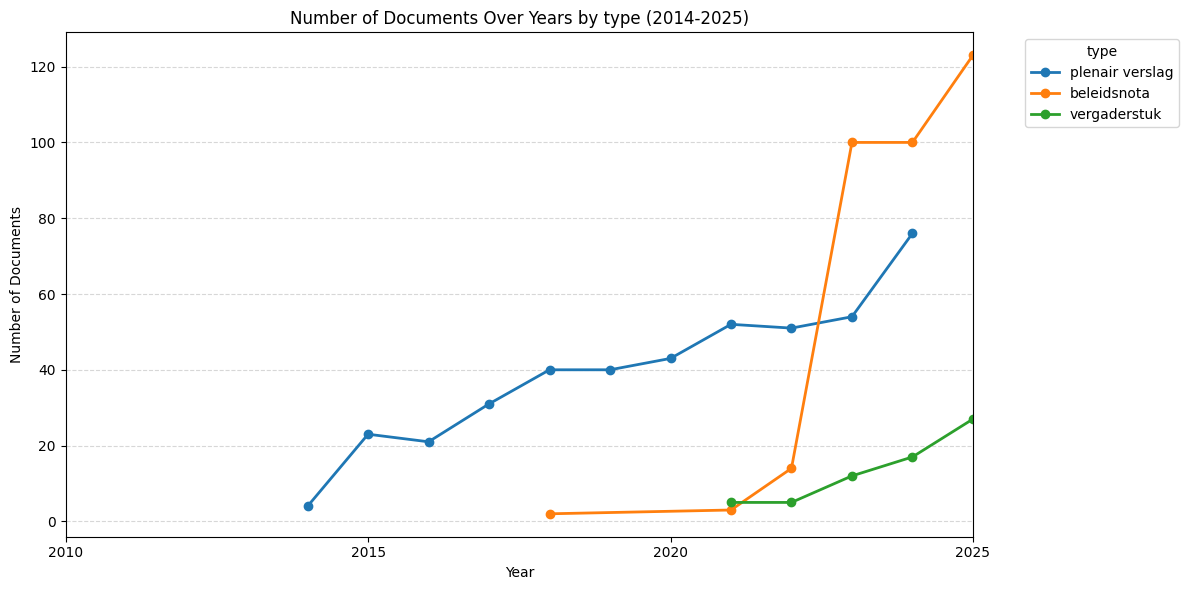

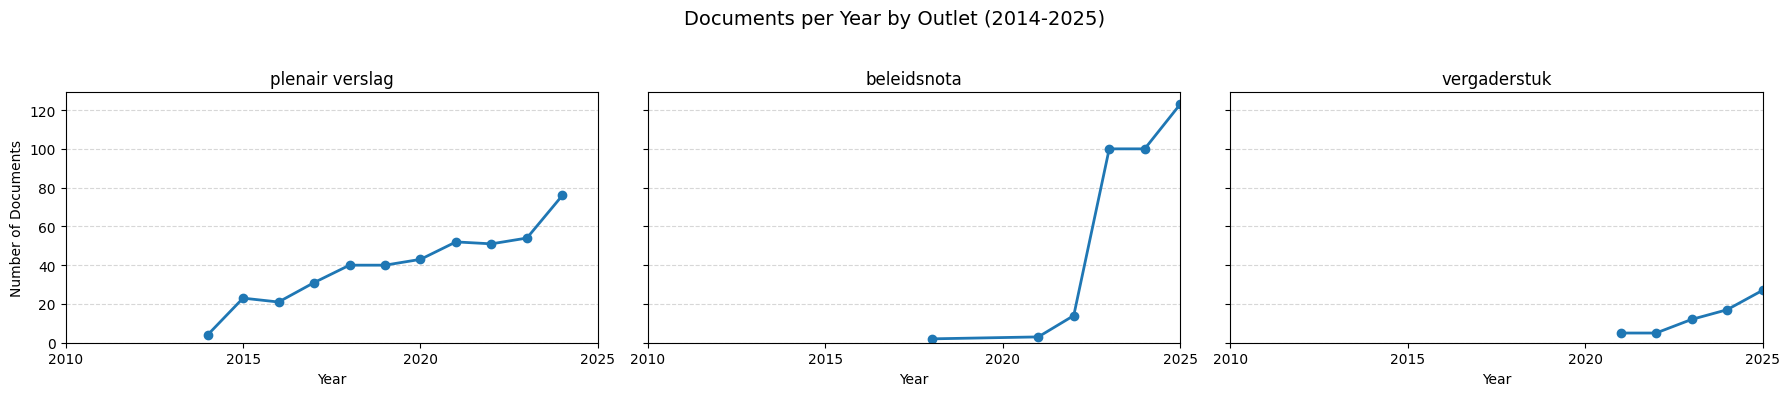

In [25]:
# ===== Config (tweak as needed) =====
TOP_TYPES   = None   # e.g. 6 to only show top-6 by volume; None = all
START_YEAR    = None   # e.g. 2000 to force a fixed start
END_YEAR      = None   # e.g. 2024 to force a fixed end
FIVE_YEAR_TICKS = True

# Prep
d = df[['type','year']].dropna().copy()
d['year'] = d['year'].astype(int)

# Count the number of articles per type per year
articles_per_year = (
    d.groupby(['type','year'])
     .size()
     .reset_index(name='count')
     .sort_values(['type','year'])
)

# Which types (optionally top-N by total volume)?
totals = articles_per_year.groupby('type')['count'].sum().sort_values(ascending=False)
types = totals.index.tolist() if TOP_TYPES is None else totals.head(TOP_TYPES).index.tolist()

# Year range (auto unless overridden)
yr_min = int(articles_per_year['year'].min()) if START_YEAR is None else int(START_YEAR)
yr_max = int(articles_per_year['year'].max()) if END_YEAR   is None else int(END_YEAR)

def five_year_ticks(start, end):
    start5 = (start // 5) * 5
    step   = 5 if (end - start) >= 5 else 1
    return np.arange(start5, end + 1, step)

# =========================
# 1) Combined plot (all types)
# =========================
plt.figure(figsize=(12, 6))
for type in types:
    od = articles_per_year[articles_per_year['type'] == type]
    plt.plot(od['year'], od['count'], marker='o', linewidth=2, label=type)

plt.xlim(yr_min, yr_max)
if FIVE_YEAR_TICKS:
    plt.xticks(five_year_ticks(yr_min, yr_max))
plt.xlabel('Year')
plt.ylabel('Number of Documents')
plt.title(f'Number of Documents Over Years by type ({yr_min}-{yr_max})')
plt.legend(title='type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================
# 2) Facet: one graph per type
# =========================
n = len(types)
ncols = 3 if n >= 3 else n
nrows = ceil(n / ncols) if n else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

# consistent y-limit for comparability
global_ymax = articles_per_year['count'].max()

for ax, type in zip(axes, types):
    od = articles_per_year[articles_per_year['type'] == type].copy()
    ax.plot(od['year'], od['count'], marker='o', linewidth=2)

    ax.set_xlim(yr_min, yr_max)
    if FIVE_YEAR_TICKS:
        ax.set_xticks(five_year_ticks(yr_min, yr_max))
    ax.set_ylim(0, global_ymax * 1.05)

    ax.set_title(type)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_xlabel('Year')

# tidy layout
for j in range(len(type), len(axes)):
    axes[j].axis('off')
axes[0].set_ylabel('Number of Documents')

fig.suptitle(f'Documents per Year by Outlet ({yr_min}-{yr_max})', y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [9]:
counts_wide = pd.crosstab(df['type'], df['year'])
# with totals:
# counts_wide = pd.crosstab(df['news_brand'], df['year'], margins=True, margins_name='Total')
counts_wide


year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
type,,,,,,,,,,,,
beleidsnota,0,0,0,0,2,0,0,3,14,100,100,123
plenair verslag,4,23,21,31,40,40,43,52,51,54,76,0
vergaderstuk,0,0,0,0,0,0,0,5,5,12,17,27


## Topic Distribution per Outlet

Stacked bar charts showing what share of each outlet's AI-related articles falls into each meta-topic category (normalised to 100%).

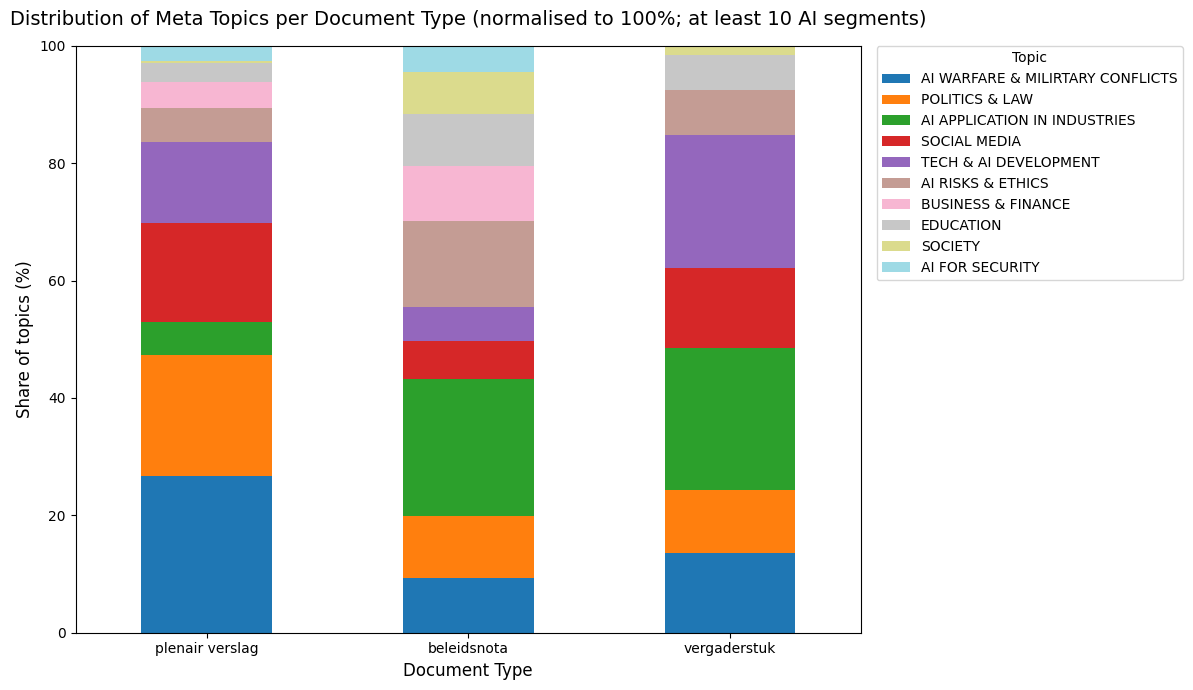

In [26]:
# =========================
# CONFIG
# =========================
BRAND_COL = "type"
TOPIC_COL = "topic_meta"

MIN_TOTAL_PER_BRAND = 10    # optional: filter out brands with very few articles
FIGSIZE = (12, 7)
ROT_X = 0                   # rotation of x-axis labels (0, 45, etc.)

# =========================
# 1) Prepare data
# =========================
# Drop missing values
df_plot = df[[BRAND_COL, TOPIC_COL]].dropna(subset=[BRAND_COL, TOPIC_COL])

# Create contingency table: counts of topics per news brand
ct = (
    df_plot
    .groupby([BRAND_COL, TOPIC_COL])
    .size()
    .unstack(fill_value=0)
)

# Filter out small brands (optional)
brand_totals = ct.sum(axis=1)
ct = ct.loc[brand_totals >= MIN_TOTAL_PER_BRAND]

# Sort topics by total frequency (for nicer order in legend)
topic_order = ct.sum(axis=0).sort_values(ascending=False).index
ct = ct[topic_order]

# Sort brands by total number of articles
brand_order = ct.sum(axis=1).sort_values(ascending=False).index
ct = ct.loc[brand_order]

# =========================
# 2) Normalise to percentages
# =========================
ct_percent = ct.div(ct.sum(axis=1), axis=0).replace([np.inf, np.nan], 0.0) * 100

# =========================
# 3) Plot
# =========================
ax = ct_percent.plot(
    kind="bar",
    stacked=True,
    figsize=FIGSIZE,
    cmap="tab20"   # nice diverse colour map
)

# Labeling and formatting
ax.set_xlabel("Document Type", fontsize=12)
ax.set_ylabel("Share of topics (%)", fontsize=12)
ax.set_title("Distribution of Meta Topics per Document Type (normalised to 100%; at least 10 AI segments)", fontsize=14, pad=15)
ax.tick_params(axis="x", labelrotation=ROT_X)

# Legend on the side for readability
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.show()


In [11]:
# Ensure 'created_at' is in datetime format
#df['created_at'] = pd.to_datetime(df['created_at'])

# Aggregate the data by country and meta topic to count occurrences
aggregated_meta = df.groupby(['type', 'topic_meta']).size().reset_index(name='count')

# Create a contingency table with countries as rows and meta topics as columns
contingency_table = aggregated_meta.pivot(index='type', columns='topic_meta', values='count').fillna(0)

# Perform the Chi-squared test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Identify the most significant meta topics per country
residuals = (contingency_table - ex) / ex**0.5

# Find the most significant residuals
significant_residuals = residuals.unstack().sort_values(ascending=False)

# Display results
print(f"Chi-squared Statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies Table: \n{ex}")

# Display the top 10 most significant residuals
print("Top 10 most significant residuals:")

Chi-squared Statistic: 200.732985080812
P-value: 7.149111349853229e-33
Degrees of Freedom: 18
Expected Frequencies Table: 
[[48.68327402 10.5480427  32.45551601 63.69395018 20.69039146 19.47330961
  53.95729537 42.59786477 11.3594306  38.54092527]
 [61.92170819 13.41637011 41.28113879 81.01423488 26.31672598 24.76868327
  68.62989324 54.18149466 14.44839858 49.02135231]
 [ 9.39501779  2.03558719  6.2633452  12.29181495  3.99288256  3.75800712
  10.41281139  8.22064057  2.19217082  7.43772242]]
Top 10 most significant residuals:


In [12]:
# Aggregate the data by country and meta topic to count occurrences
aggregated_meta = df.groupby(['type', 'topic_meta']).size().reset_index(name='count')

# Create a contingency table with countries as rows and meta topics as columns
contingency_table = aggregated_meta.pivot(index='type', columns='topic_meta', values='count').fillna(0)

# Perform the Chi-squared test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Calculate residuals
residuals = (contingency_table - ex) / ex**0.5

# Flatten the residuals DataFrame and sort by residual values
significant_residuals = residuals.unstack().sort_values(ascending=False).reset_index()
significant_residuals.columns = ['Meta', 'type', 'Residual']

# Display the top 10 most significant residuals in a table
top_10_residuals = significant_residuals.head(10)
print(top_10_residuals)

                               Meta             type  Residual
0      AI APPLICATION IN INDUSTRIES      beleidsnota  4.488347
1                           SOCIETY      beleidsnota  4.047196
2  AI WARFARE & MILIRTARY CONFLICTS  plenair verslag  3.886966
3                 AI RISKS & ETHICS      beleidsnota  3.079614
4             TECH & AI DEVELOPMENT     vergaderstuk  2.772890
5                      SOCIAL MEDIA  plenair verslag  2.692436
6                   POLITICS & LAW   plenair verslag  2.579586
7               BUSINESS & FINANCE       beleidsnota  2.486355
8                         EDUCATION      beleidsnota  2.385459
9      AI APPLICATION IN INDUSTRIES     vergaderstuk  2.154879


## Most Distinctive Topics per Outlet (Chi-Square Analysis)

To identify which meta-topics are *over-* or *under-represented* per outlet relative to what would be expected by chance, we run a chi-square test of independence on the outlet × topic contingency table and inspect the standardised residuals.

A large positive residual means an outlet covers that topic significantly more than average; a large negative residual means significantly less.

In [13]:
BRAND_COL = "type"
TOPIC_COL = "topic_meta"
TOP_N = 10

# 1) Contingency table (brands × topics)
aggregated_meta = (
    df.groupby([BRAND_COL, TOPIC_COL])
      .size()
      .reset_index(name='count')
)

contingency = (
    aggregated_meta
    .pivot(index=BRAND_COL, columns=TOPIC_COL, values='count')
    .fillna(0)
    .astype(int)
)

# Drop brands/topics that are all zero (safeguard)
contingency = contingency.loc[contingency.sum(axis=1) > 0, contingency.sum(axis=0) > 0]

if contingency.empty or contingency.shape[0] < 2 or contingency.shape[1] < 2:
    raise ValueError("Not enough non-empty rows/cols to run chi-square.")

# 2) Chi-square on counts
chi2, p, dof, expected = chi2_contingency(contingency.values, correction=False)

# Wrap expected as DataFrame aligned to contingency
ex_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

# 3) Standardized residuals
# Guard: avoid divide-by-zero if any expected cell is (near) zero
den = np.sqrt(ex_df.replace(0, np.nan))
residuals = (contingency - ex_df) / den

# 4) Tidy long format (consistent column names!)
residuals_flat = (
    residuals.stack()
             .rename("Residual")
             .reset_index()
             .rename(columns={BRAND_COL: "news_brand", TOPIC_COL: "topic_meta"})
)

# 5) Split + take top/bottom per brand
positive = residuals_flat[residuals_flat["Residual"] > 0].copy()
negative = residuals_flat[residuals_flat["Residual"] < 0].copy()

def top_per_brand(df_in, n=TOP_N, ascending=False):
    return (df_in.sort_values(["news_brand", "Residual"], ascending=[True, ascending])
                 .groupby("news_brand", as_index=False)
                 .head(n))

top_pos = top_per_brand(positive, n=TOP_N, ascending=False)
top_neg = top_per_brand(negative, n=TOP_N, ascending=True)

# 6) Build summary dicts (brand → list of topics)
most_distinct = (top_pos.groupby("news_brand")["topic_meta"]
                      .apply(list)
                      .to_dict())
least_distinct = (top_neg.groupby("news_brand")["topic_meta"]
                      .apply(list)
                      .to_dict())

# 7) Assemble display table
brands_order = list(contingency.index)  # keep contingency row order
table_df = pd.DataFrame({
    "News Brand": brands_order,
    "Most Distinct Topics": [", ".join(most_distinct.get(b, [])) for b in brands_order],
    "Least Distinct Topics": [", ".join(least_distinct.get(b, [])) for b in brands_order],
})

print(table_df)

# 8) APA-style line
chi2_apa = f"χ²({dof}) = {chi2:.2f}, p < .001" if p < 0.001 else f"χ²({dof}) = {chi2:.2f}, p = {p:.3f}"
print("\nChi-squared Test Result (APA Style):")
print(chi2_apa)


        News Brand                               Most Distinct Topics  \
0      beleidsnota  AI APPLICATION IN INDUSTRIES, SOCIETY, AI RISK...   
1  plenair verslag  AI WARFARE & MILIRTARY CONFLICTS, SOCIAL MEDIA...   
2     vergaderstuk  TECH & AI DEVELOPMENT, AI APPLICATION IN INDUS...   

                               Least Distinct Topics  
0  AI WARFARE & MILIRTARY CONFLICTS, SOCIAL MEDIA...  
1  AI APPLICATION IN INDUSTRIES, SOCIETY, AI RISK...  
2  BUSINESS & FINANCE , AI FOR SECURITY, POLITICS...  

Chi-squared Test Result (APA Style):
χ²(18) = 200.73, p < .001


In [14]:
table_df.to_excel('distinct_topics.xlsx')

In [15]:
df['year'].value_counts()

year
2024    193
2023    166
2025    150
2022     70
2021     60
2020     43
2018     42
2019     40
2017     31
2015     23
2016     21
2014      4
Name: count, dtype: int64

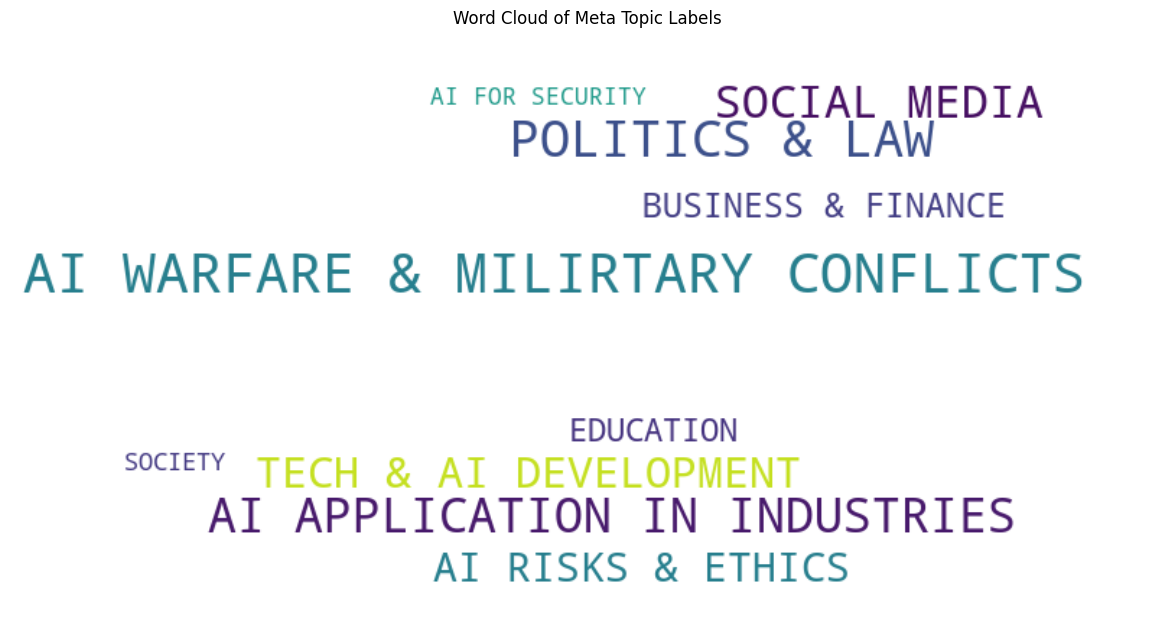

In [16]:
#word cloud meta topics
from wordcloud import WordCloud

# 2) Compute frequencies of each label
label_counts = df['topic_meta'].value_counts().to_dict()

# 3) Create a WordCloud object
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    collocations=False  # ensure multi‐word labels are kept intact
)

# 4) Generate the cloud from your frequencies
wc.generate_from_frequencies(label_counts)

# 5) Display it
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Meta Topic Labels')
plt.show()


In [17]:
# amount of different topics
print("Number of unique topics:", df['topic_meta'].nunique())

Number of unique topics: 10


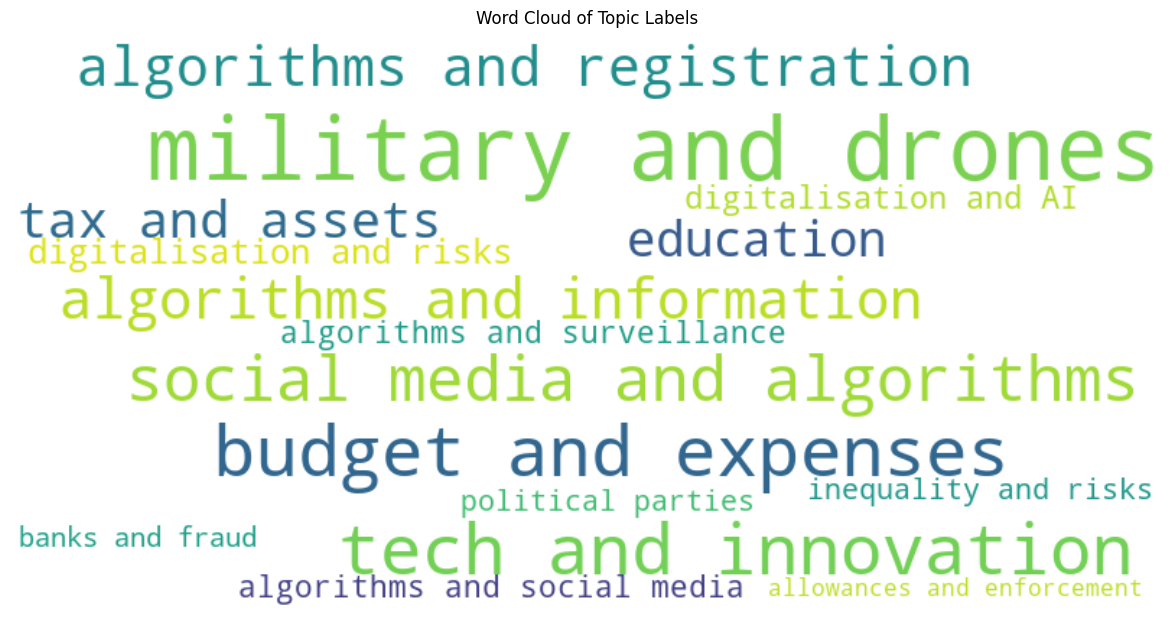

In [18]:
#word cloud labels

# 2) Compute frequencies of each label
label_counts = df['topic_label'].value_counts().to_dict()

# 3) Create a WordCloud object
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    collocations=False  # ensure multi‐word labels are kept intact
)

# 4) Generate the cloud from your frequencies
wc.generate_from_frequencies(label_counts)

# 5) Display it
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Topic Labels')
plt.show()


## Topic Visualisations

Word clouds and bar charts summarising the overall distribution of meta-topics and sub-topic labels across the full dataset.

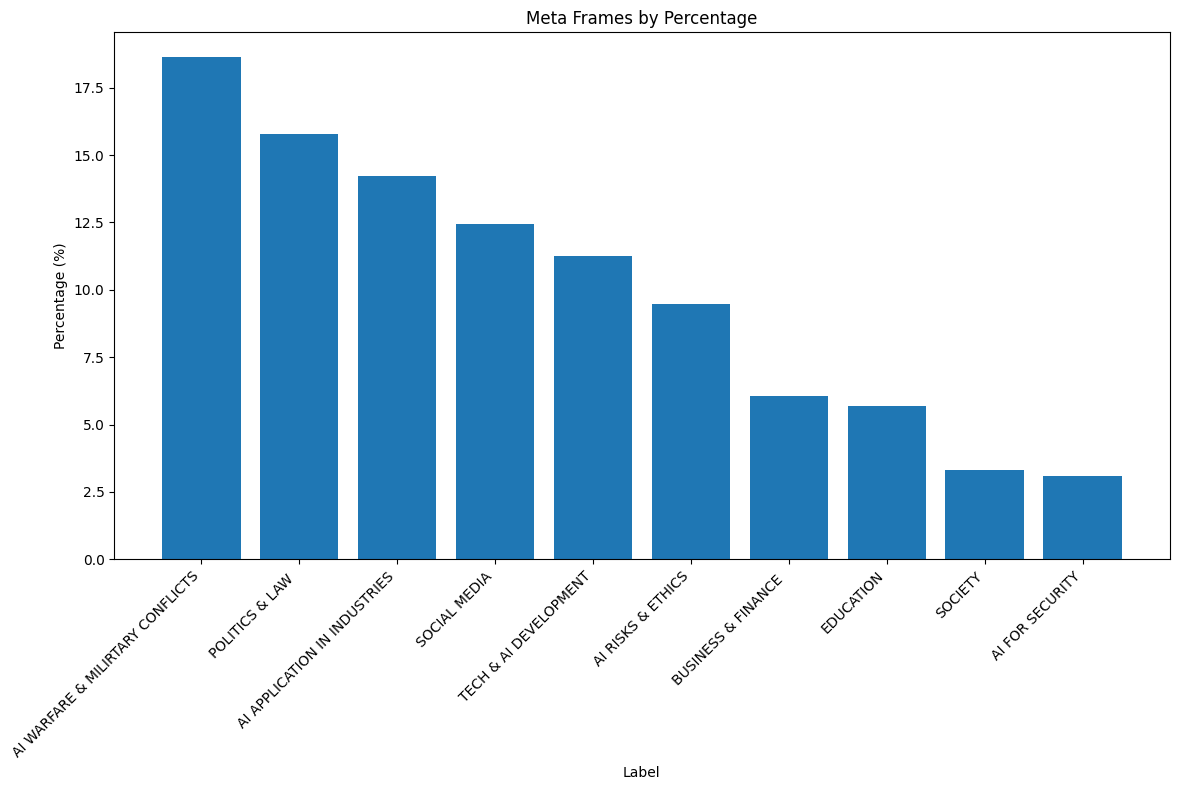

In [19]:
# Overview macro topics (percentages instead of raw counts)
meta_percent = df['topic_meta'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 8))
plt.bar(meta_percent.index, meta_percent.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Percentage (%)')
plt.title('Meta Frames by Percentage')
plt.tight_layout()
plt.show()


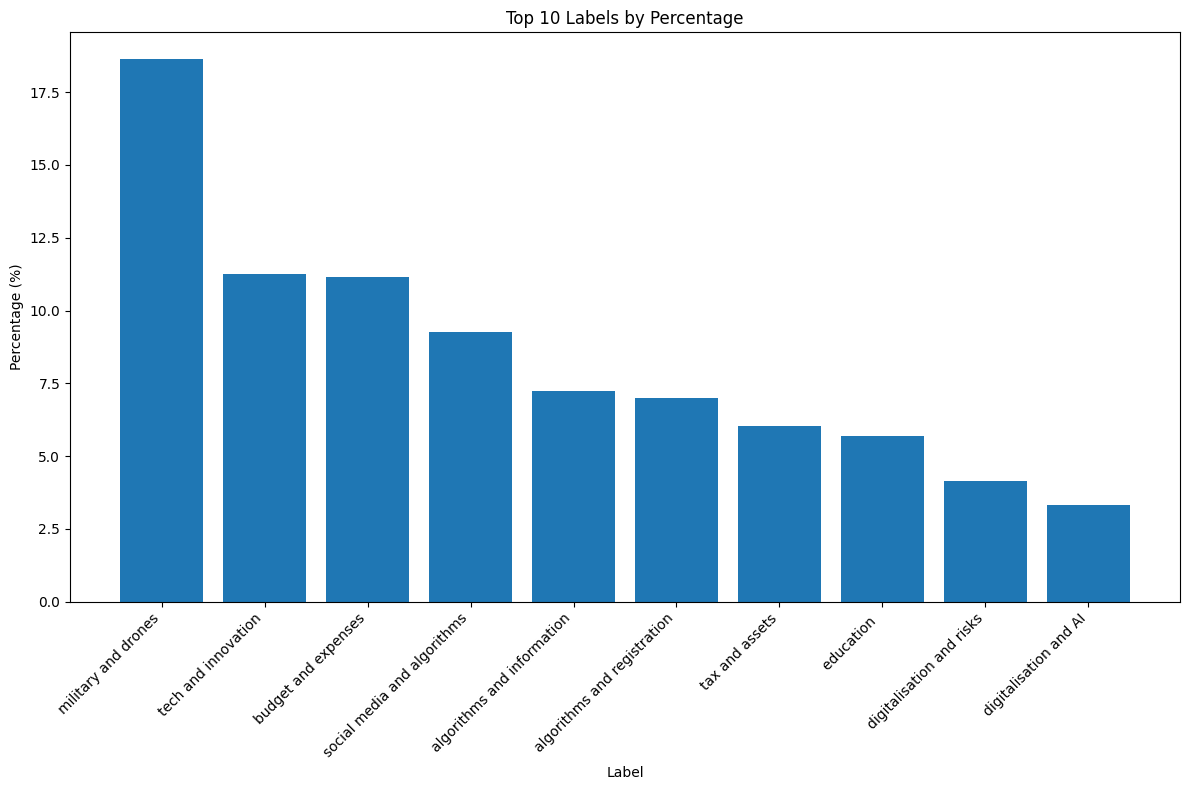

In [20]:
# Set how many top labels you want to display
top_n = 10   # ← change this to whatever you need

# Compute percentages
label_percent = df['topic_label'].value_counts(normalize=True) * 100

# Keep only the top X
label_percent_top = label_percent.head(top_n)

plt.figure(figsize=(12, 8))
plt.bar(label_percent_top.index, label_percent_top.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Percentage (%)')
plt.title(f'Top {top_n} Labels by Percentage')
plt.tight_layout()
plt.show()


## Topic Distribution per Year

Each subplot shows the top-N meta-topics (as % of all articles that year), making it easy to compare how the topic mix shifts year by year.

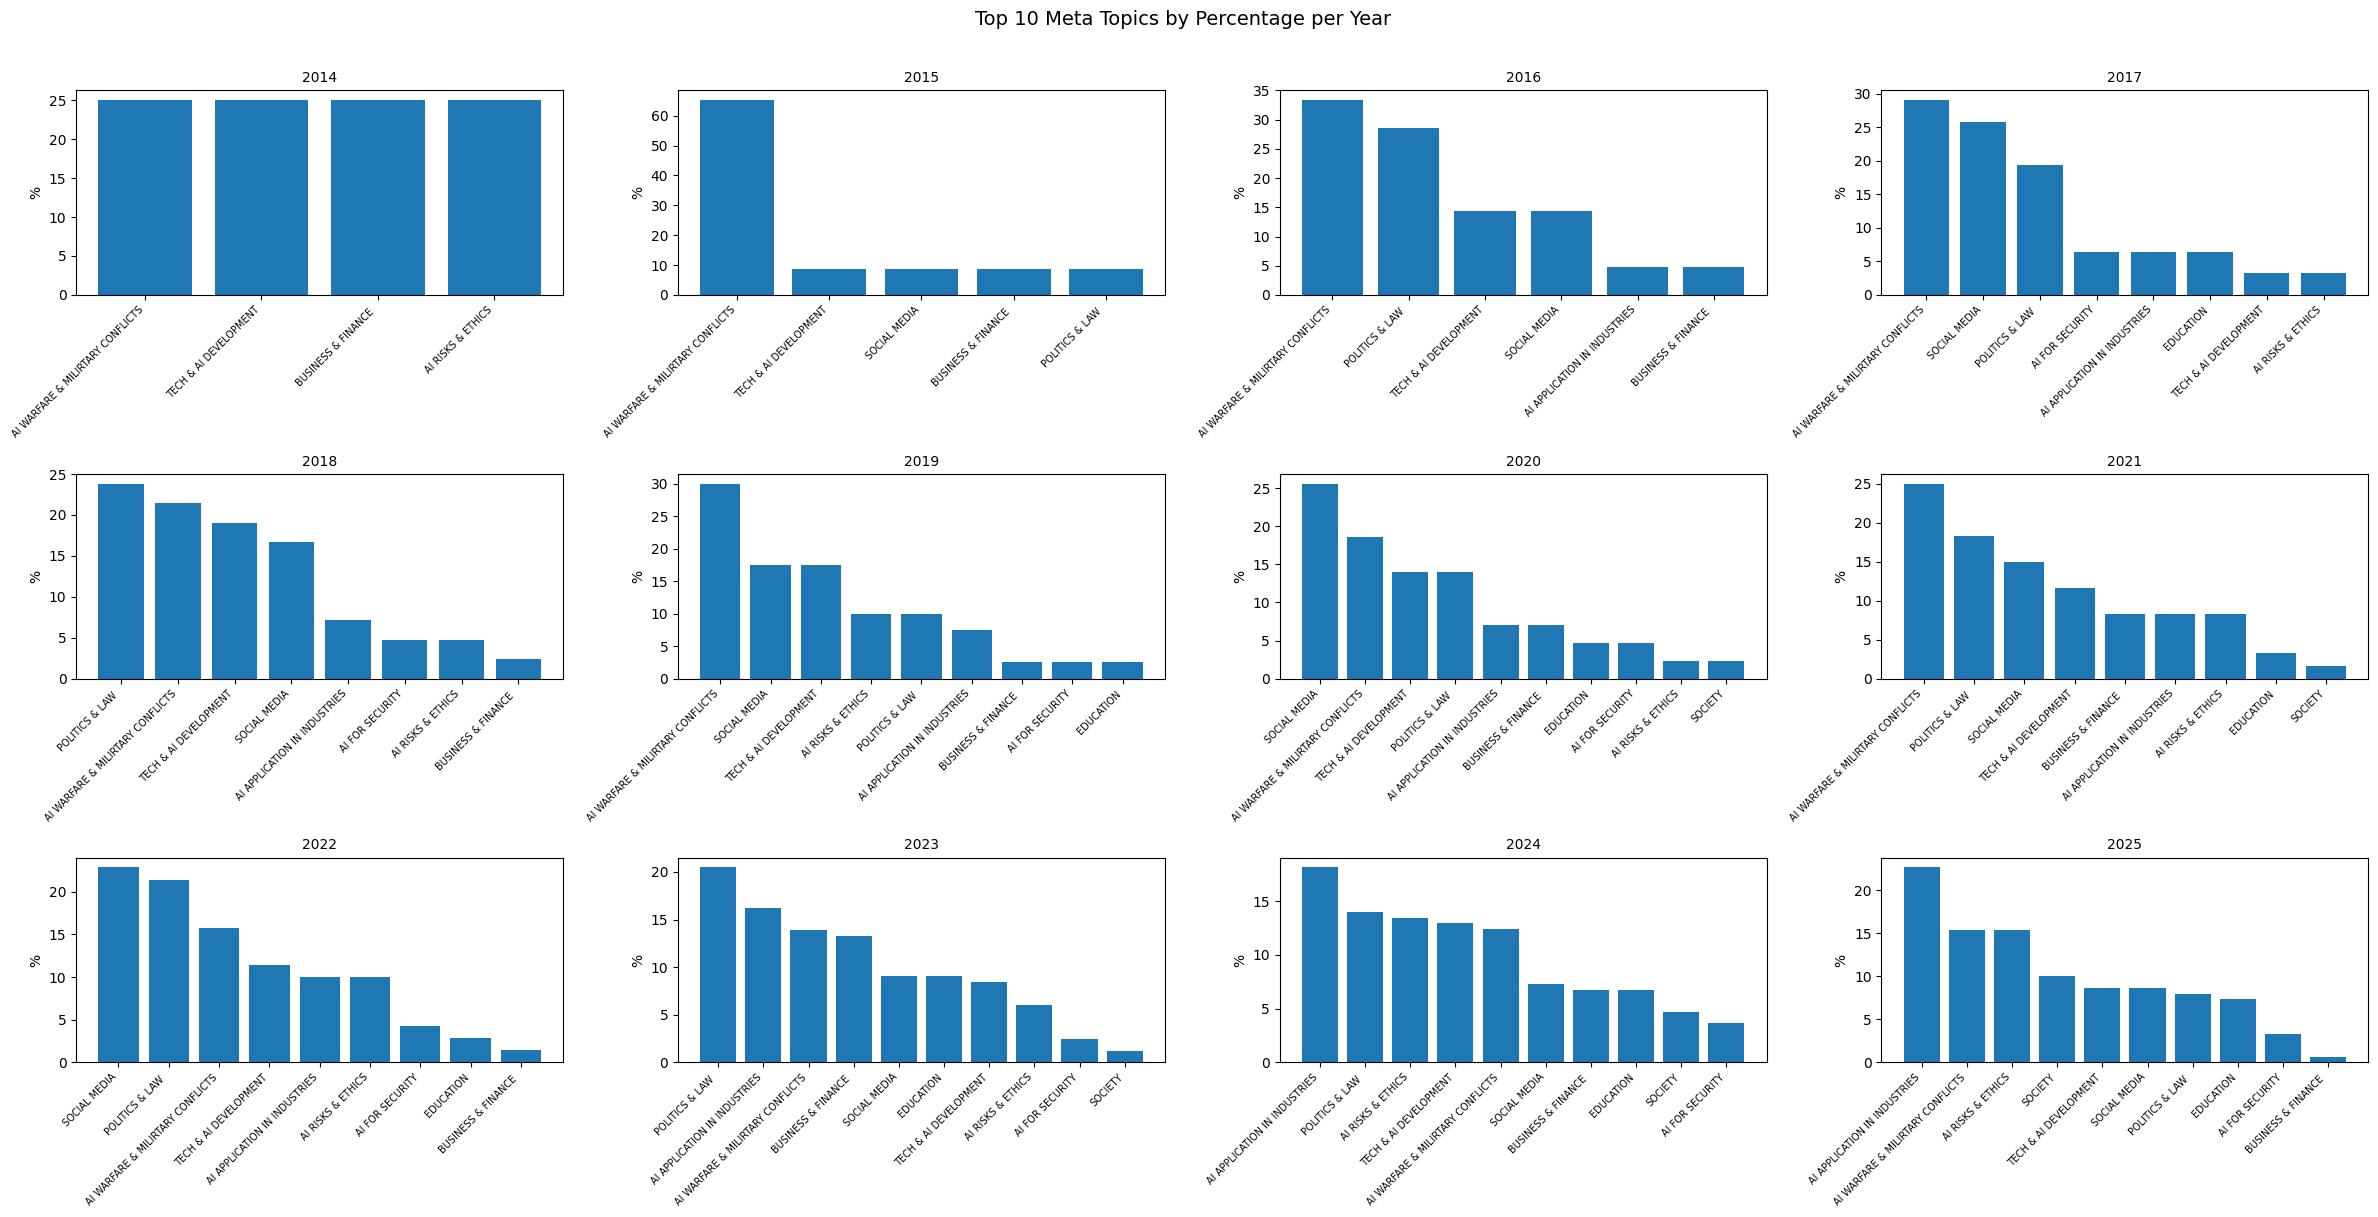

In [21]:
#Bar chart per year - adjust to macro, meta or label
top_n = 10  # number of labels to display per year
label = 'Meta'  #'Macro' #'Meta' #'Label'

years = sorted(df['year'].unique())

ncols = 4
nrows = ceil(len(years) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, yr in zip(axes, years):
    df_year = df[df['year'] == yr]
    label_percent_top = (
        df_year['topic_meta']
        .value_counts(normalize=True)
        .mul(100)
        .sort_values(ascending=False)
        .head(top_n)
    )
    ax.bar(range(len(label_percent_top)), label_percent_top.values)
    ax.set_xticks(range(len(label_percent_top)))
    ax.set_xticklabels(label_percent_top.index, rotation=45, ha='right', fontsize=7)
    ax.set_title(str(yr), fontsize=10)
    ax.set_ylabel('%')

for j in range(len(years), len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Top {top_n} {label} Topics by Percentage per Year', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Topic Trends Over Time

Line charts showing how the share of each meta-topic evolves across the full time period (2015–2025). The highlighted version draws attention to the five most frequent topics while graying out the rest.

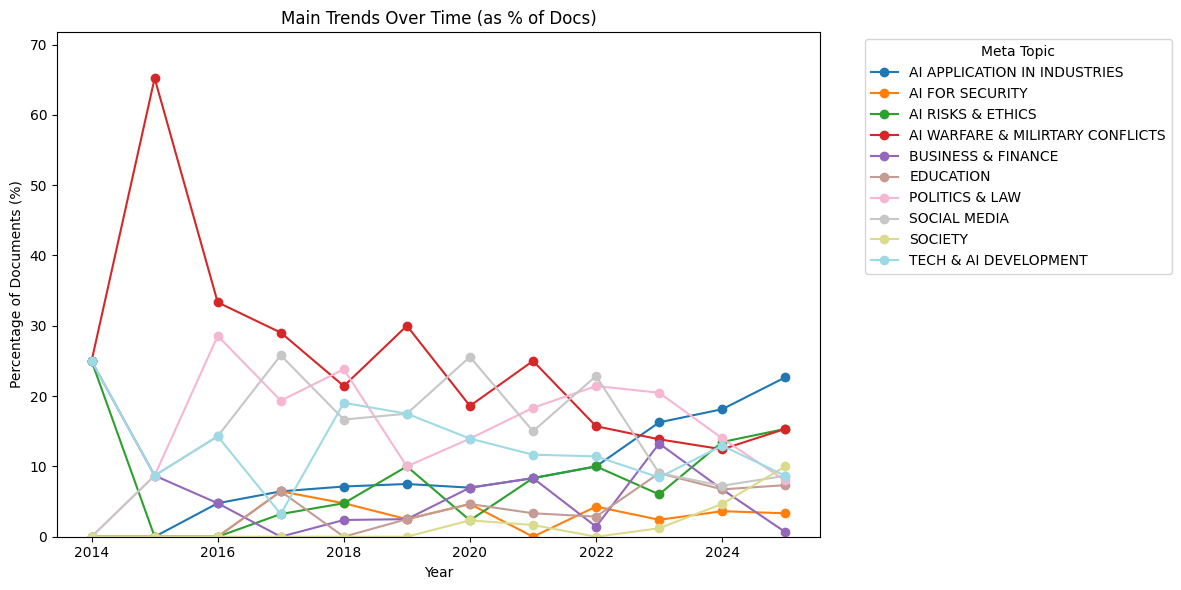

In [22]:
# 1. Build counts per year × meta-topic
counts = (
    df
    .groupby(['year', 'topic_meta'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 2. Convert to percentages per year
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# 3. Pick a qualitative colormap with exactly as many bins as you have topics
n_topics = pct.shape[1]
cmap = plt.get_cmap('tab20', n_topics)   # swap in 'tab20b', 'gist_ncar', etc. if you exceed 20
colors = cmap(np.arange(n_topics))

# 4. Plot each line
plt.figure(figsize=(12, 6))
for color, topic in zip(colors, pct.columns):
    plt.plot(
        pct.index,          # x = year
        pct[topic],         # y = % share
        marker='o',
        label=topic,
        color=color
    )

# 5. Tidy up
plt.xlabel('Year')
plt.ylabel('Percentage of Documents (%)')
plt.title('Main Trends Over Time (as % of Docs)')
plt.ylim(0, pct.values.max() * 1.1)  # add some headroom
plt.legend(
    title='Meta Topic',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


In [23]:
# pick the top X most frequent
meta_counts = df['topic_meta'].value_counts()
toptopics = meta_counts.head(5).index.tolist()
toptopics

['AI WARFARE & MILIRTARY CONFLICTS',
 'POLITICS & LAW ',
 'AI APPLICATION IN INDUSTRIES',
 'SOCIAL MEDIA',
 'TECH & AI DEVELOPMENT']

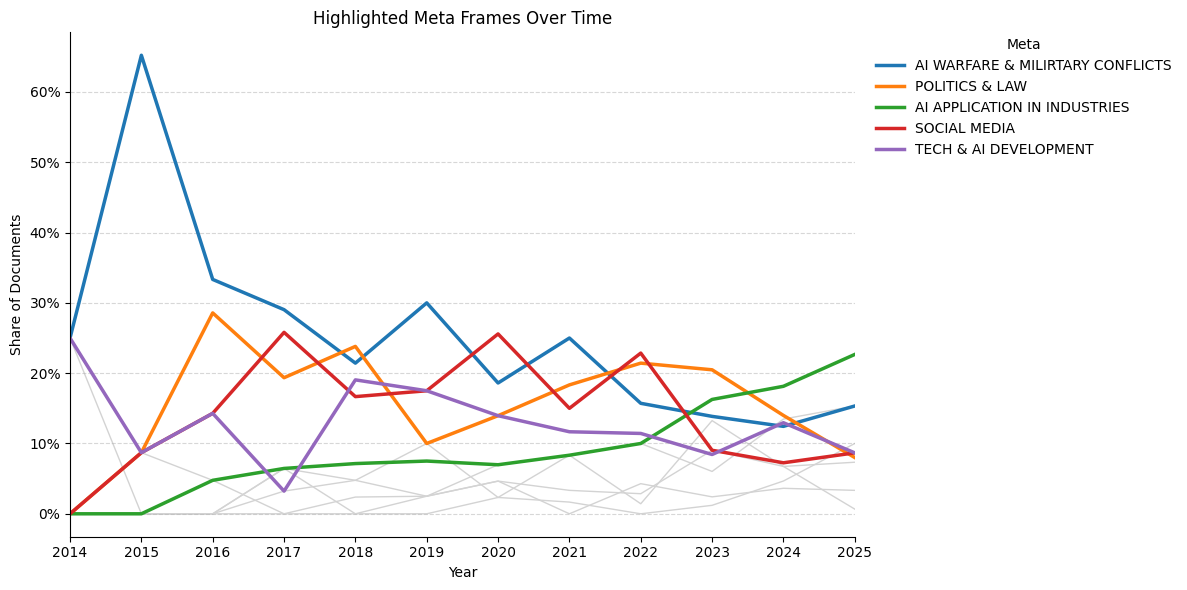

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

# plot all lines in light grey
for col in pct.columns:
    ax.plot(pct.index, pct[col], color='lightgrey', linewidth=1, zorder=1)

# highlight selected topics
for topic, color in zip(toptopics, plt.get_cmap('tab10').colors):
    ax.plot(pct.index, pct[topic], 
            label=topic, 
            color=color, 
            linewidth=2.5, 
            zorder=2)

# axes, labels & formatting
ax.set_xlim(pct.index.min(), pct.index.max())
ax.set_xlabel('Year')
ax.set_ylabel('Share of Documents')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xticks(pct.index)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.title('Highlighted Meta Frames Over Time')

# ─── Legend outside plot ─────────────────────────────────
ax.legend(
    title="Meta",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()
